In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Step1:準備資料

In [2]:
iris=datasets.load_iris()

In [3]:
X=iris.data
X=X[:,2:4]

# Step2:建立模型
## n_clusters: k值
## init: 'random' / 'k-means++' / 自行給定
## max_iter: 最多迭代次數
## tol: 中心點誤差忍受 (最好不要設0)
## random_state: 隨機種子

In [4]:
KM = KMeans(n_clusters=3, init='random', random_state=5)
KM.fit(X)
print(KM)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe6 in position 18: illegal multibyte sequence


KMeans(init='random', n_clusters=3, random_state=5)


C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


# Step3: 進行分群

In [5]:
KM.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

# Step4: 圖像化結果

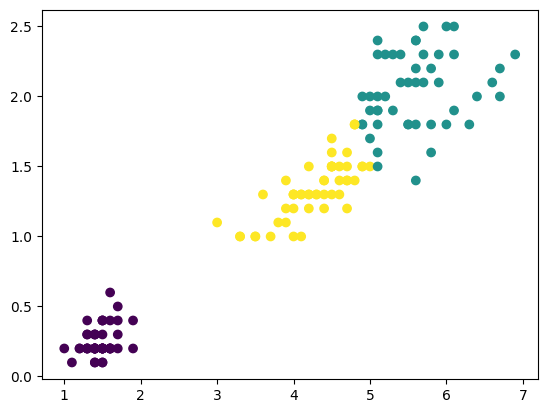

In [6]:
plt.scatter(X[:,0],X[:,1],c = KM.predict(X))

# 額外補充: 與真實情況對照

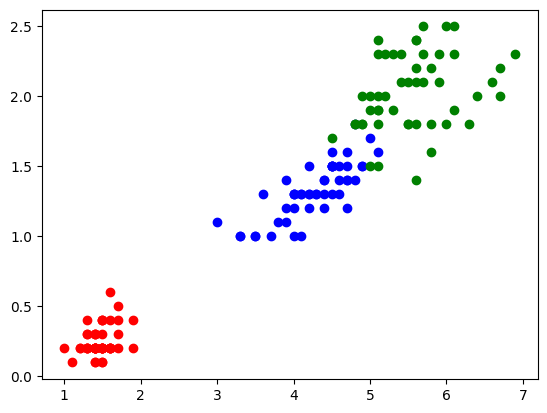

In [7]:
iris=datasets.load_iris()
features=iris.data
target=iris.target
target_names=iris.target_names
labels=target_names[target]

setosa_petal_length=features[labels=='setosa',2]
setosa_petal_width=features[labels=='setosa',3]
setosa=np.c_[setosa_petal_length,setosa_petal_width]

versicolor_petal_length=features[labels=='versicolor',2]
versicolor_petal_width=features[labels=='versicolor',3]
versicolor=np.c_[versicolor_petal_length,versicolor_petal_width]

virginica_petal_length=features[labels=='virginica',2]
virginica_petal_width=features[labels=='virginica',3]
virginica=np.c_[virginica_petal_length,virginica_petal_width]

plt.scatter(setosa[:,0],setosa[:,1],color='red')
plt.scatter(versicolor[:,0],versicolor[:,1],color='blue')
plt.scatter(virginica[:,0],virginica[:,1],color='green')

# K-Medoids
## 中心點為實際樣本點，且新中心點的決定方式為選取使群內距離和最小的點
> pip install scikit-learn-extra

In [8]:
try:
    from sklearn_extra.cluster import KMedoids
except Exception:
    from sklearn.metrics import pairwise_distances

    class KMedoids:
        def __init__(self, n_clusters=3, init='random', random_state=None, max_iter=300):
            self.n_clusters = n_clusters
            self.init = init
            self.random_state = random_state
            self.max_iter = max_iter

        def fit(self, X):
            X = np.asarray(X)
            rng = np.random.default_rng(self.random_state)
            distances = pairwise_distances(X)

            medoid_indices = rng.choice(len(X), self.n_clusters, replace=False)
            for _ in range(self.max_iter):
                labels = np.argmin(distances[:, medoid_indices], axis=1)
                new_medoid_indices = medoid_indices.copy()

                for cluster_id in range(self.n_clusters):
                    members = np.where(labels == cluster_id)[0]
                    if len(members) == 0:
                        continue
                    intra_distances = distances[np.ix_(members, members)].sum(axis=1)
                    new_medoid_indices[cluster_id] = members[np.argmin(intra_distances)]

                if np.array_equal(new_medoid_indices, medoid_indices):
                    break
                medoid_indices = new_medoid_indices

            self.medoid_indices_ = medoid_indices
            self.cluster_centers_ = X[medoid_indices]
            self.labels_ = np.argmin(distances[:, medoid_indices], axis=1)
            return self

        def predict(self, X):
            return np.argmin(pairwise_distances(np.asarray(X), self.cluster_centers_), axis=1)

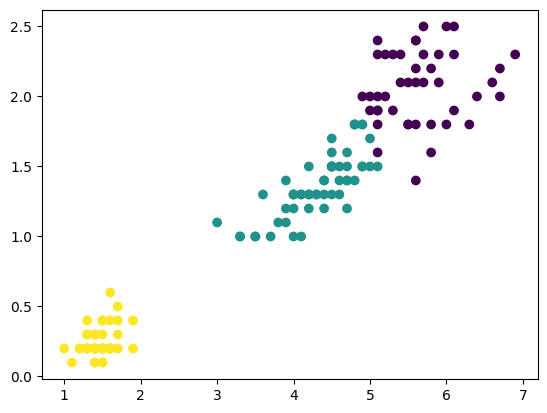

In [9]:
KMed = KMedoids(n_clusters=3,init='random',random_state=5)
KMed.fit(X)
KMed.predict(X)
plt.scatter(X[:,0],X[:,1],c = KMed.predict(X))

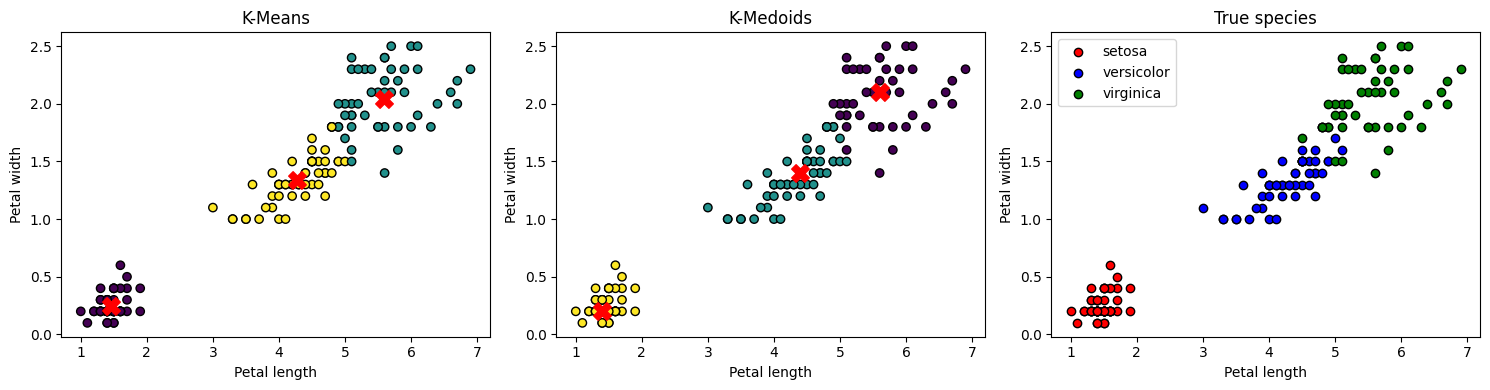

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X[:, 0], X[:, 1], c=KM.predict(X), cmap='viridis', edgecolor='k')
axes[0].scatter(KM.cluster_centers_[:, 0], KM.cluster_centers_[:, 1], c='red', s=160, marker='X')
axes[0].set_title('K-Means')

axes[1].scatter(X[:, 0], X[:, 1], c=KMed.predict(X), cmap='viridis', edgecolor='k')
axes[1].scatter(KMed.cluster_centers_[:, 0], KMed.cluster_centers_[:, 1], c='red', s=160, marker='X')
axes[1].set_title('K-Medoids')

axes[2].scatter(setosa[:, 0], setosa[:, 1], color='red', edgecolor='k', label='setosa')
axes[2].scatter(versicolor[:, 0], versicolor[:, 1], color='blue', edgecolor='k', label='versicolor')
axes[2].scatter(virginica[:, 0], virginica[:, 1], color='green', edgecolor='k', label='virginica')
axes[2].set_title('True species')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')

plt.tight_layout()
plt.show()